e:\Application\Anaconda\envs\image2text\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
e:\Application\Anaconda\envs\image2text\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Small_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Small_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


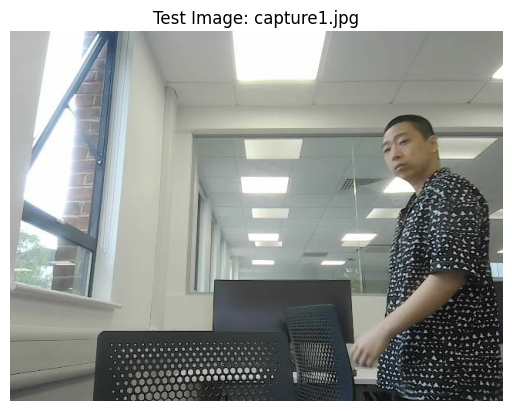

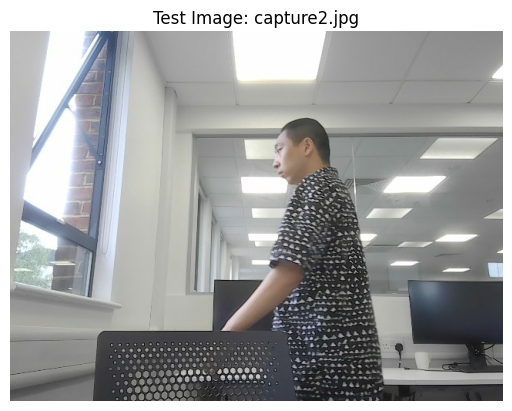

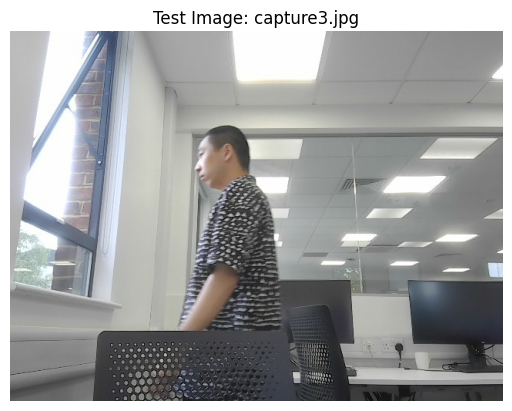

In [1]:
# 导入必要的库
import cv2
import numpy as np
import json
import torch
from ultralytics import YOLO
import matplotlib.pyplot as plt
%matplotlib inline
from datetime import datetime, timedelta

# 导入 processing_logic 模块
import backend.processing_logic as processing_logic

# --- 模拟帧序列 ---
# 准备一个图像文件列表来模拟3秒的帧序列
# 为简单起见，我们重复使用同一张图片，并模拟时间戳
image_paths = [
    'capture1.jpg',
    'capture2.jpg', # 您可以换成不同的图片来模拟变化
    'capture3.jpg'
]
yolo_model_path = 'backend/resource/models/yolov8n-seg.pt'
ollama_api_url = 'http://localhost:11434/api/generate'  # 模拟 API URL
deepseek_model_name = 'deepseek-r1:8b'

# 模拟时间戳
base_time = datetime.now()
capture_times = [(base_time + timedelta(seconds=i)).strftime("%Y-%m-%d %H:%M:%S") for i in range(len(image_paths))]

# 加载 YOLO 模型
yolo_model = YOLO(yolo_model_path)

# 加载二次分类模型（模拟，使用 MobileNetV3-Small）
secondary_model = processing_logic.load_secondary_model('mobilenet_v3_small', num_classes=4)

for i, image_path in enumerate(image_paths):
    # 加载图像
    image_bgr = cv2.imread(image_path)
    if image_bgr is None:
        raise FileNotFoundError(f"Image not found at {image_path}")

    # 显示图像以确认加载正确
    plt.imshow(cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB))
    plt.title(f'Test Image: {image_path}')
    plt.axis('off')
    plt.show()



Processing frame sequence...
  - Processing frame 1...

0: 480x640 1 person, 121.0ms
Speed: 3.8ms preprocess, 121.0ms inference, 2.5ms postprocess per image at shape (1, 3, 480, 640)
  - Processing frame 2...

0: 480x640 1 person, 1 cup, 1 tv, 73.5ms
Speed: 1.4ms preprocess, 73.5ms inference, 4.4ms postprocess per image at shape (1, 3, 480, 640)
  - Processing frame 3...

0: 480x640 1 person, 1 cup, 1 tv, 75.0ms
Speed: 1.7ms preprocess, 75.0ms inference, 4.2ms postprocess per image at shape (1, 3, 480, 640)
Sequence processing complete.
\n--- Aggregated JSON for LLM ---
{
  "summary": "This is a sequence of image frames. Analyze the objects and their changes over time.",
  "frames": [
    {
      "frame_id": 1,
      "capture_time": "2025-07-27 13:51:54",
      "detections": [
        {
          "class": "person",
          "group": "person",
          "confidence": 0.9127306342124939,
          "bbox": [
            440,
            103,
            637,
            479
          ],


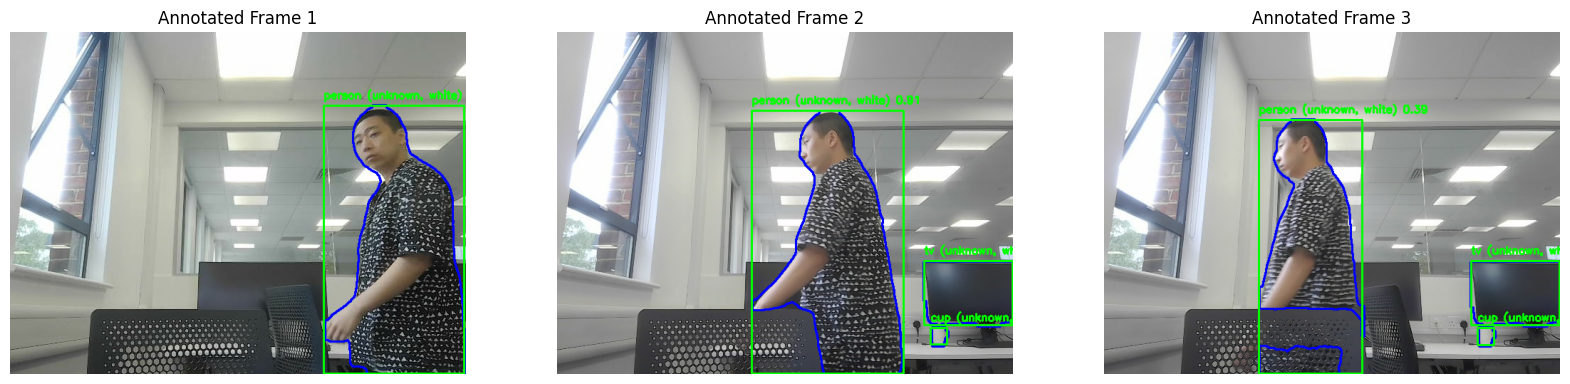

In [6]:
# --- 循环处理每一帧 ---
all_detections = []
annotated_images = []

print("Processing frame sequence...")
for i, path in enumerate(image_paths):
    print(f"  - Processing frame {i+1}...")
    image_bgr = cv2.imread(path)
    
    # 对每一帧进行物体检测
    detections_list, annotated_image = processing_logic.detect_objects_yolo(
        image_bgr, yolo_model, secondary_model=secondary_model, color_space='HSL'
    )
    
    all_detections.append(detections_list)
    annotated_images.append(annotated_image)

print("Sequence processing complete.")

# --- 汇总结果 ---
# 使用我们新创建的函数来格式化序列数据
json_sequence_detections = processing_logic.format_sequence_detections_for_llm(
    all_detections, capture_times
)

# 打印为LLM准备的JSON
print("\\n--- Aggregated JSON for LLM ---")
print(json_sequence_detections)

# --- 可视化标注后的帧 ---
fig, axes = plt.subplots(1, len(annotated_images), figsize=(20, 5))
for i, img in enumerate(annotated_images):
    axes[i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[i].set_title(f'Annotated Frame {i+1}')
    axes[i].axis('off')
plt.show()

In [7]:
# 基于帧序列的问答循环
print("Enter your question about the image sequence (or 'quit' to exit):")
question = "What did you see?"

while True:
    # question = input("> ").strip()
    # if question.lower() == 'quit':
    #     break
    # if not question:
    #     continue

    print(f"\\nQuestion: {question}")
    print("Generating answer, please wait...")

    # 使用汇总后的JSON数据进行提问
    final_answer, complete_response, metrics = processing_logic.answer_question_with_deepseek(
        json_sequence_detections,
        question,
        ollama_api_url,
        deepseek_model_name
    )
    
    print(f"Answer: {final_answer}")
    print("--------------------")
    print(f"Metrics: {metrics}")
    print("Complete Response:")
    print(complete_response)
    break

Enter your question about the image sequence (or 'quit' to exit):
\nQuestion: What did you see?
Generating answer, please wait...
Answer: Okay, I've analyzed these frames:

*   **Frame 1:** You saw one white person located roughly from top-left to bottom-right of this scene (using bbox coordinates).
*   **Frame 2:** You still saw the same white person, now positioned more towards the left side. Additionally, a white TV was detected and placed in the right part of the frame.
*   **Frame 3:** The white person moved further left again. A small white cup appeared on the lower-right corner near the TV.
--------------------
Metrics: {'question': 'What did you see?', 'start_time': 1753621597.3696578, 'inference_time': 18.13498020172119, 'memory_mb': 609.3515625, 'cpu_percent': 0.0, 'retry_attempts': 0, 'status': 'success'}
Complete Response:
<think>
Hmm, let's tackle this query about analyzing image frames.

The user has provided a JSON-like structure with three consecutive frames. Each frame